In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

from dask.diagnostics import ProgressBar

In [2]:
import sys
sys.path.append('/meddy/simingzhang/Analysis/python/python3/newcode/SF3_RLS/')

In [3]:
import importlib
import StrucFunction
importlib.reload(StrucFunction)
from StrucFunction import *

In [50]:
import scipy.io as sio
def corr_homo_SF3(D1L,D2L,D3LLL,D1T,D2T,D3LTT,cross):
    d3lll=D3LLL-D1L**3-3*(D2L-D1L**2)*D1L
    d3ltt=D3LTT-D1L*D1T**2-2*(cross-D1L*D1T)*D1T-(D2T-D1T**2)*D1L
    return d3lll,d3ltt

# 1. correction

### assuming $u_{2}=u_{2}^{\prime}+U_{2}, u_{1}=u_{1}^{\prime}+U_{1}$
### where $<u^{\prime}>=0$, $<>$ is ensamble average, $U=const$ is the background flow, $<\delta U_{L}^{2}>=<\delta U_{L}>^{2}$
### $\delta u_{L}=u_{2}-u_{1}=U_{2}-U_{1}+u_{2}^{\prime}-u_{1}^{\prime}=\delta u_{L}^{\prime}+\delta U_{L}$
### $\delta u_{T}=\delta u_{T}^{\prime}+\delta U_{T}$
###
### noted $<\delta u_{L}>={\delta U_{L}=D1_{L}}$
### where $D1_{L} $ is the actual SF1 in data
###
### $\delta u_{L}^{3}=\delta u_{L}^{\prime \ 3}+\delta U_{L}^{3}+3\delta u_{L}^{\prime \ 2}\delta U_{L}+3\delta u_{L}^{\prime}\delta U_{L}^{2}$
### ensamble average:
### $<\delta u_{L}^{3}>=<\delta u_{L}^{\prime \ 3}>+<\delta U_{L}^{3}>+3<\delta u_{L}^{\prime \ 2}> <\delta U_{L}>$
### $<\delta u_{L}^{3}>=<\delta u_{L}^{\prime \ 3}>+D1_{L}^{3}+3<\delta u_{L}^{\prime \ 2}> D1_{L}$
### $\underbrace{D3_{LLL}}_{SF3}=\underbrace{<\delta u_{L}^{\prime \ 3}>}_{pure \ turbluence}+\underbrace{D1_{L}^{3}}_{pure \ background}+ \underbrace{3 (D2_{L}-D1_{L}^{2}) D1_{L}}_{cross \ term}$

### similarly
### $<\delta u_{L}\delta u_{T}^{2}>=<\delta u_{L}^{\prime}\delta u_{T}^{\prime \ 2}>+<\delta U_{L}\delta U_{T}^{2}>+2<\delta u_{L}^{\prime}\delta u_{T}^{\prime}> \delta U_{T}+<\delta u_{T}^{\prime \ 2}> \delta U_{L}$

###
### $\underbrace{D3_{LTT}}_{SF3}=\underbrace{<\delta u_{L}^{\prime}\delta u_{T}^{\prime \ 2}>}_{pure \ turbulence}+\underbrace{D1_{L}D1_{T}^{2}}_{pure \ backgroud}+\underbrace{ 2crossD D1_{T} + [D2_{T}-D1_{T}^{2}] D1_{L}}_{cross \ term}$
### where $crossD=\underbrace{<\delta u_{L} \delta u_{T}>}_{isotropy \ cross \ m}-D1_{L}D1_{T}$

### all we want is pure turbulence terms, which is homogeneous

# 2. 2D turbulence

In [128]:
A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/hitroughsmall_shao.mat')
pairs_sep=A['pairs_sep']
r2=np.squeeze(A['dist_axis'])
def flatten_mat_cell(x):
    return np.array([v.item() for v in x.flat])
    
D1L_hit = flatten_mat_cell(pairs_sep['dul_m'])
D2L_hit = flatten_mat_cell(pairs_sep['dul2_m'])
D3LLL_hit = flatten_mat_cell(pairs_sep['dul3_m'])

D1T_hit = flatten_mat_cell(pairs_sep['dut_m'])
D2T_hit = flatten_mat_cell(pairs_sep['dut2_m'])
D3LTT_hit = flatten_mat_cell(pairs_sep['dultt_m'])

cross_hit = flatten_mat_cell(pairs_sep['cross_m'])

A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/HIT2d_Eulerian_SF3.mat')
dist_axis=np.squeeze(A['r'])[1:]
SF3=(A['S3L1_time']+A['S3T1_time'])[:,1:].T

In [129]:
d3lll_hit,d3ltt_hit=corr_homo_SF3(D1L_hit,D2L_hit,D3LLL_hit,D1T_hit,D2T_hit,D3LTT_hit,cross_hit)

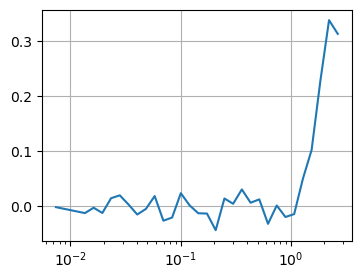

In [130]:
plt.figure(figsize=(4,3))
plt.semilogx(r2,cross_hit)
plt.grid(True)

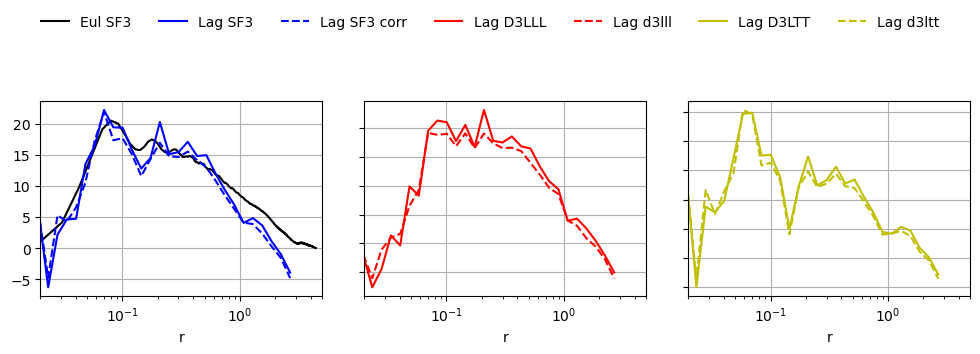

In [132]:
import matplotlib.pyplot as plt
import numpy as np

# 创建 Figure
fig = plt.figure(figsize=(12, 3))

# 子图 1
ax1 = fig.add_subplot(131)
# 注意：必须给所有需要出现在图例中的线加上 label
line1, = ax1.semilogx(dist_axis, np.nanmean(SF3, axis=1)/dist_axis, 'k-', label='Eul SF3')
line2, = ax1.semilogx(r2, (D3LLL_hit+D3LTT_hit)/r2, 'b-', label='Lag SF3')
# line3, = ax1.semilogx(r2, (D3LLL_hit)/r2, 'r-', label='Lag D3LLL')
# line4, = ax1.semilogx(r2, (D3LTT_hit)/r2, 'y-', label='Lag D3LTT')
line7, = ax1.semilogx(r2, (d3ltt_hit+d3lll_hit)/r2, 'b--', label='Lag SF3 corr')

ax1.grid(True)
ax1.set_xlabel('r')
ax1.set_xlim(2e-2,5)

# 子图 2
ax2 = fig.add_subplot(132)
line3,=ax2.semilogx(r2, (D3LLL_hit)/r2, 'r-',label='Lag D3LLL') 
line5, = ax2.semilogx(r2, (d3lll_hit)/r2, 'r--', label='Lag d3lll')
ax2.grid(True)
ax2.set_xlabel('r')
ax2.set_yticklabels([])
ax2.set_xlim(2e-2,5)

# 子图 3
ax3 = fig.add_subplot(133)
line4,=ax3.semilogx(r2, (D3LTT_hit)/r2, 'y-',  label='Lag D3LTT')
line6,=ax3.semilogx(r2, (d3ltt_hit)/r2, 'y--', label='Lag d3ltt')
ax3.grid(True)
ax3.set_xlabel('r')
ax3.set_yticklabels([])
ax3.set_xlim(2e-2,5)

# ===== 核心美化部分 =====
# 1. 调整子图布局
# top=0.80 : 顶部留出 20% 的空白给图例（因为图例在上面）
# bottom=0.15 : 底部留一点空间给 X 轴标签
plt.subplots_adjust(top=0.80, bottom=0.15, wspace=0.15)



fig.legend(handles=[line1, line2, line7, line3, line5, line4, line6], 
           loc='lower center', 
           bbox_to_anchor=(0.5, 1.0), 
           ncol=7, 
           fontsize='medium', 
           frameon=False)

plt.show()

# 3. Hf EXP-F-P289

In [142]:
A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/wave289roughsmall.mat')
# A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/wave289rough.mat')

pairs_sep=A['pairs_sep']
r1=np.squeeze(A['dist_axis'])
def flatten_mat_cell(x):
    return np.array([v.item() for v in x.flat])
    
D1L_w = flatten_mat_cell(pairs_sep['dul_m'])
D2L_w = flatten_mat_cell(pairs_sep['dul2_m'])
D3LLL_w = flatten_mat_cell(pairs_sep['dul3_m'])

D1T_w = flatten_mat_cell(pairs_sep['dut_m'])
D2T_w = flatten_mat_cell(pairs_sep['dut2_m'])
D3LTT_w = flatten_mat_cell(pairs_sep['dultt_m'])

cross_w = flatten_mat_cell(pairs_sep['cross_m'])

A=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/wave_Eulerian_bin_SF3.mat')
dist_axis=np.squeeze(A['dist_axis'])[:]
SF3w=np.squeeze((A['SF3'])[:]).T

In [143]:
d3lll_w,d3ltt_w=corr_homo_SF3(D1L_w,D2L_w,D3LLL_w,D1T_w,D2T_w,D3LTT_w,cross_w)

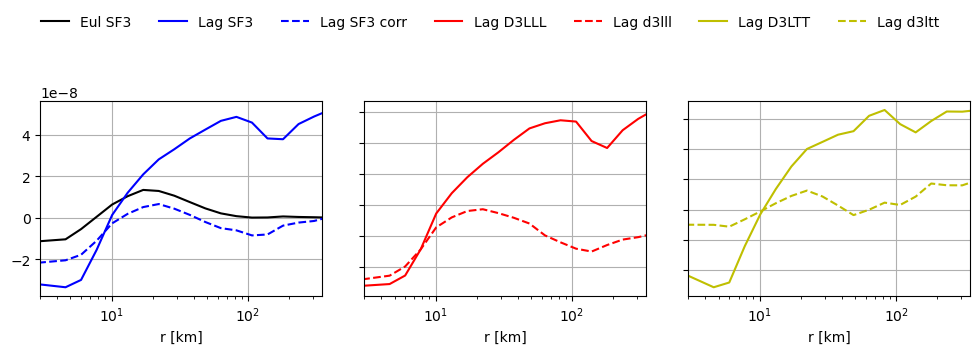

In [144]:
import matplotlib.pyplot as plt
import numpy as np

# 创建 Figure
fig = plt.figure(figsize=(12, 3))

# 子图 1
ax1 = fig.add_subplot(131)
# 注意：必须给所有需要出现在图例中的线加上 label
line1, = ax1.semilogx(dist_axis*1e-3, (SF3w)/dist_axis, 'k-', label='Eul SF3')
line2, = ax1.semilogx(r1*1e-3, (D3LLL_w+D3LTT_w)/r1, 'b-', label='Lag SF3')
# line3, = ax1.semilogx(r1, (D3LLL_w)/r1, 'r-', label='Lag D3LLL')
# line4, = ax1.semilogx(r1, (D3LTT_w)/r1, 'y-', label='Lag D3LTT')
line7, = ax1.semilogx(r1*1e-3, (d3ltt_w+d3lll_w)/r1, 'b--', label='Lag SF3 corr')
ax1.set_xlim([3,350])
ax1.grid(True)
ax1.set_xlabel('r [km]')

# 子图 2
ax2 = fig.add_subplot(132)
line3, =ax2.semilogx(r1*1e-3, (D3LLL_w)/r1, 'r-',label='Lag D3LLL') 
line5, = ax2.semilogx(r1*1e-3, (d3lll_w)/r1, 'r--', label='Lag d3lll')
ax2.grid(True)
ax2.set_xlabel('r [km]')
ax2.set_yticklabels([])
ax2.set_xlim([3,350])

# 子图 3
ax3 = fig.add_subplot(133)
line4, =ax3.semilogx(r1*1e-3, (D3LTT_w)/r1, 'y-',  label='Lag D3LTT')
line6,=ax3.semilogx(r1*1e-3, (d3ltt_w)/r1, 'y--', label='Lag d3ltt')
ax3.grid(True)
ax3.set_xlabel('r [km]')
ax3.set_yticklabels([])
ax3.set_xlim([3,350])

# ===== 核心美化部分 =====
# 1. 调整子图布局
# top=0.80 : 顶部留出 20% 的空白给图例（因为图例在上面）
# bottom=0.15 : 底部留一点空间给 X 轴标签
plt.subplots_adjust(top=0.80, bottom=0.15, wspace=0.15)



fig.legend(handles=[line1, line2,line7, line3, line5, line4, line6 ], 
           loc='lower center', 
           bbox_to_anchor=(0.5, 1.0), 
           ncol=7, 
           fontsize='medium', 
           frameon=False)

plt.show()

# 4. Sm EXP-F-P289

In [148]:
A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/nowave289roughsmall.mat')
# A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/nowave289rough.mat')
pairs_sep=A['pairs_sep']
r1=np.squeeze(A['dist_axis'])
def flatten_mat_cell(x):
    return np.array([v.item() for v in x.flat])
    
D1L_nw = flatten_mat_cell(pairs_sep['dul_m'])
D2L_nw = flatten_mat_cell(pairs_sep['dul2_m'])
D3LLL_nw = flatten_mat_cell(pairs_sep['dul3_m'])

D1T_nw = flatten_mat_cell(pairs_sep['dut_m'])
D2T_nw = flatten_mat_cell(pairs_sep['dut2_m'])
D3LTT_nw = flatten_mat_cell(pairs_sep['dultt_m'])

cross_nw = flatten_mat_cell(pairs_sep['cross_m'])

A=sio.loadmat('/meddy/simingzhang/Data/Parcels_data/nowave_Eulerian_bin_SF3.mat')
dist_axis=np.squeeze(A['dist_axis'])[:]
SF3nw=np.squeeze((A['SF3'])[:]).T

In [149]:
d3lll_nw,d3ltt_nw=corr_homo_SF3(D1L_nw,D2L_nw,D3LLL_nw,D1T_nw,D2T_nw,D3LTT_nw,cross_nw)

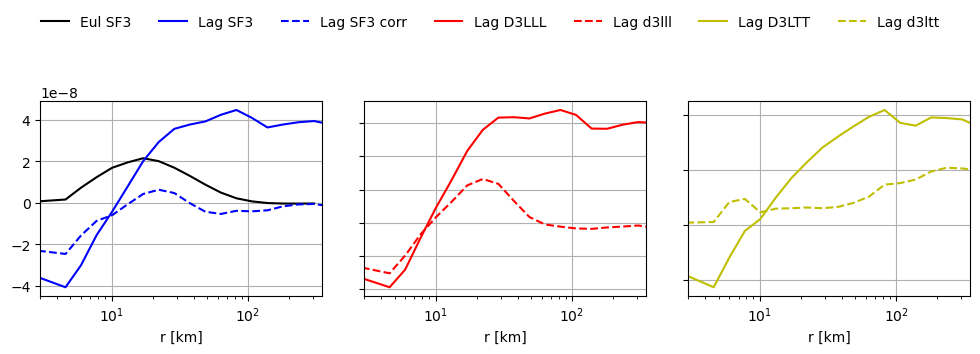

In [151]:
import matplotlib.pyplot as plt
import numpy as np

# 创建 Figure
fig = plt.figure(figsize=(12, 3))

# 子图 1
ax1 = fig.add_subplot(131)
# 注意：必须给所有需要出现在图例中的线加上 label
line1, = ax1.semilogx(dist_axis*1e-3, (SF3nw)/dist_axis, 'k-', label='Eul SF3')
line2, = ax1.semilogx(r1*1e-3, (D3LLL_nw+D3LTT_nw)/r1, 'b-', label='Lag SF3')
# line3, = ax1.semilogx(r1, (D3LLL_nw)/r1, 'r-', label='Lag D3LLL')
# line4, = ax1.semilogx(r1, (D3LTT_nw)/r1, 'y-', label='Lag D3LTT')
line7, = ax1.semilogx(r1*1e-3, (d3ltt_nw+d3lll_nw)/r1, 'b--', label='Lag SF3 corr')

ax1.grid(True)
ax1.set_xlabel('r [km]')
ax1.set_xlim([3,350])

# 子图 2
ax2 = fig.add_subplot(132)
line3,=ax2.semilogx(r1*1e-3, (D3LLL_nw)/r1, 'r-',label='Lag D3LLL') 
line5, = ax2.semilogx(r1*1e-3, (d3lll_nw)/r1, 'r--', label='Lag d3lll')
ax2.grid(True)
ax2.set_xlabel('r [km]')
ax2.set_yticklabels([])
ax2.set_xlim([3,350])

# 子图 3
ax3 = fig.add_subplot(133)
line4,=ax3.semilogx(r1*1e-3, (D3LTT_nw)/r1, 'y-',  label='Lag D3LTT')
line6,=ax3.semilogx(r1*1e-3, (d3ltt_nw)/r1, 'y--', label='Lag d3ltt')
ax3.grid(True)
ax3.set_xlabel('r [km]')
ax3.set_yticklabels([])
ax3.set_xlim([3,350])

# ===== 核心美化部分 =====
# 1. 调整子图布局
# top=0.80 : 顶部留出 20% 的空白给图例（因为图例在上面）
# bottom=0.15 : 底部留一点空间给 X 轴标签
plt.subplots_adjust(top=0.80, bottom=0.15, wspace=0.15)



fig.legend(handles=[line1, line2, line7, line3, line5, line4, line6], 
           loc='lower center', 
           bbox_to_anchor=(0.5, 1.0), 
           ncol=7, 
           fontsize='medium', 
           frameon=False)

plt.show()